In [1]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
import pickle as pkl

from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist

## Load solutions 

In [251]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
):
    # Path to results 
    path_to_results = Path(path_to_results)

    # Final cell type dictionary
    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                uncertainty_path = (
                    exp_folder
                    / "uncertainty_annotation"
                    / "candidates_with_uncertainties.csv"
                )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():

                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [252]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg_loop3 = yaml.safe_load(fb)
protocol_cols_loop3 = annotation_cfg_loop3["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_loop3 = yaml.safe_load(fb)
ubound_dict_loop3, lbound_dict_loop3 = annotation_cfg_bound_loop3["ubound_dict"],  annotation_cfg_bound_loop3["lbound_dict"]

# Collect per parameter bounds 
bounds_loop3 = {}
for param in lbound_dict_loop3:
    bounds_loop3[param] = (lbound_dict_loop3[param], ubound_dict_loop3[param])

### Collect optimized samples 

In [253]:
path_to_results_loop3 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop3_replicate/")
paths_loop3 = os.listdir(path_to_results_loop3)

In [254]:
cell_types = ["CD14Mono", 
              "CD16Mono"]

In [255]:
raw_solutions_loop3 = load_pure_cell_type_solutions(
    path_to_results_loop3,
    paths_loop3,
    cell_types,
)

100%|██████████| 6/6 [00:17<00:00,  2.99s/it]


In [256]:
# Concatenate data frame 
raw_solutions_loop3 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop3.items()
}

### Initialize targets

Only 4 types were optimized 

In [257]:
# Cell type fractions
celltype_fraction = {"CD14Mono": 0.05,
                    "CD16Mono": 0.05}

columns_of_interest_loop1 = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
    "il7_[ng_ml]",
    "mcsf_[ng_ml]",
    "ly_cocktail_[ul/well]"
]

columns_of_interest_loop3 = columns_of_interest_loop1 + []

### Filter values

In [258]:
# Collect filtered and annotated data frames 
filtered_df_loop3_monocytes, annotated_df_loop3_monocytes = manual_filtering(
    {"CD16Mono": raw_solutions_loop3["CD16Mono"],
     "CD14Mono": raw_solutions_loop3["CD14Mono"]}, 
    bounds=bounds_loop3,
    columns_to_keep=columns_of_interest_loop3, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols_loop3, 
    use_bounds_filter=True, 
    use_fraction_filter=True,
    use_oxygen_days_filter=True
)

In [259]:
# Filtered and unfiltered solutions 
for ct in filtered_df_loop3_monocytes:
    print(f"Filtered {ct} number of solutions:", filtered_df_loop3_monocytes[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", raw_solutions_loop3[ct].shape[0], "\n")

Filtered CD16Mono number of solutions: 4537
Unfiltered CD16Mono number of solutions: 31300 

Filtered CD14Mono number of solutions: 368
Unfiltered CD14Mono number of solutions: 31350 



In [260]:
cd16_prop = filtered_df_loop3_monocytes["CD16Mono"]
cd14_prop = filtered_df_loop3_monocytes["CD14Mono"]

## Plot uncertainty calibrations 

<Axes: xlabel='CD16Mono_prop', ylabel='target_ct_loss_std'>

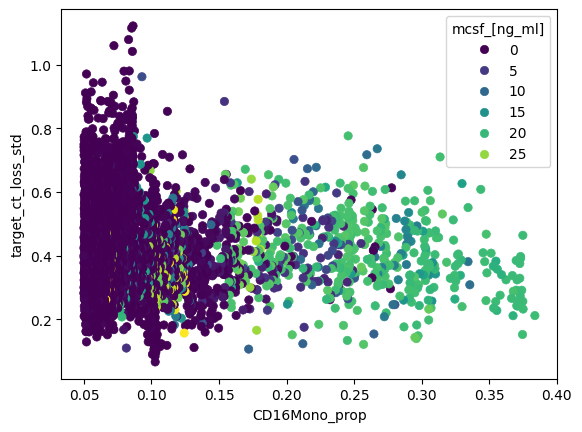

In [261]:
sns.scatterplot(cd16_prop, x="CD16Mono_prop", y="target_ct_loss_std", hue='mcsf_[ng_ml]', palette="viridis", edgecolor=None)

<Axes: xlabel='CD14Mono_prop', ylabel='target_ct_loss_std'>

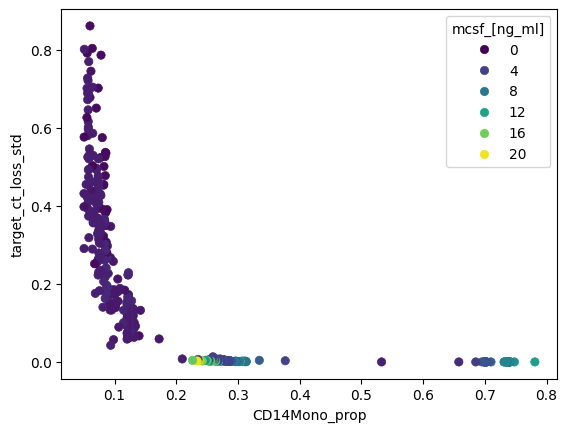

In [262]:
sns.scatterplot(cd14_prop, x="CD14Mono_prop", y="target_ct_loss_std", hue='mcsf_[ng_ml]', palette="viridis", edgecolor=None)

# Cluster analysis

## CD14Mono

In [263]:
cd14mono = filtered_df_loop3_monocytes["CD14Mono"]

In [264]:
cd14mono_prot = cd14mono.loc[:, protocol_cols_loop3]
cd14mono_adata = sc.AnnData(X=cd14mono_prot, obs=cd14mono.loc[:, ['CD14Mono_prop', 'filtering_step']])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [265]:
sc.pp.log1p(cd14mono_adata)
sc.pp.pca(cd14mono_adata)

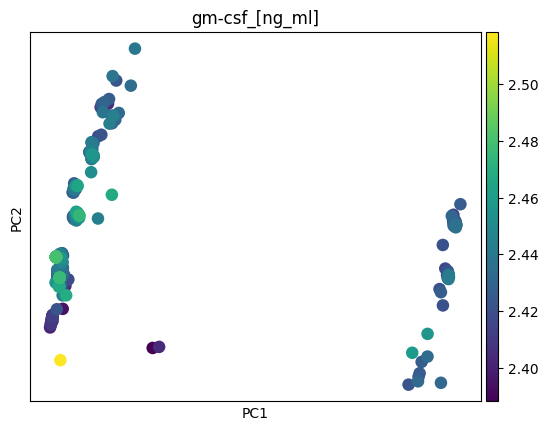

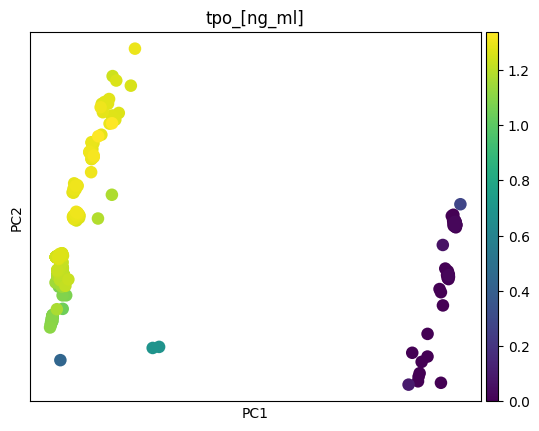

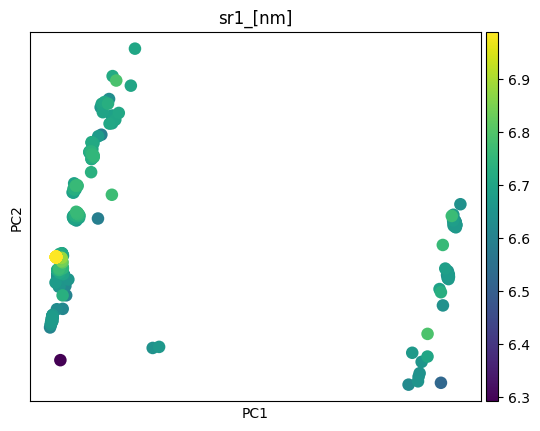

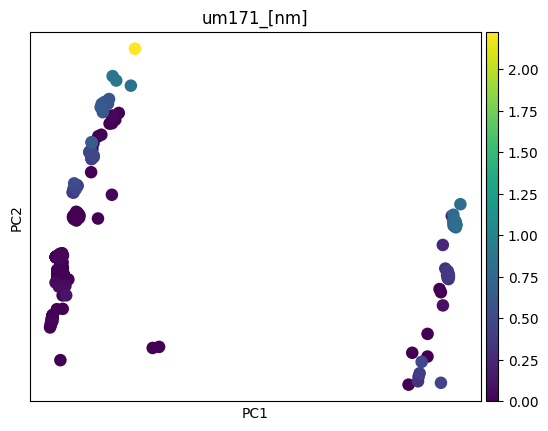

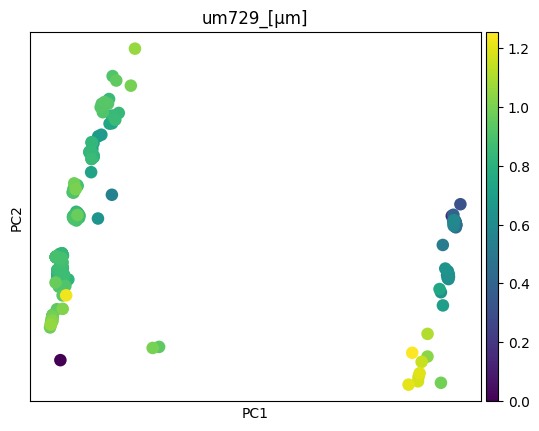

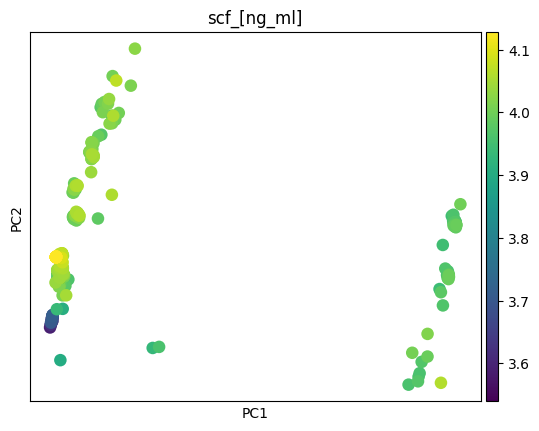

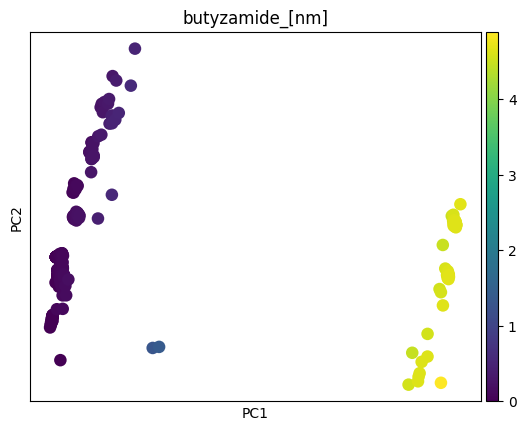

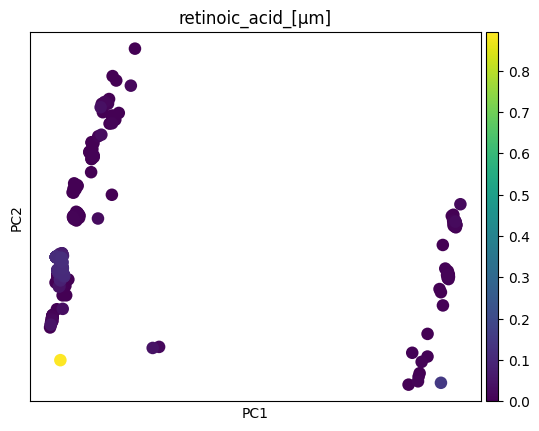

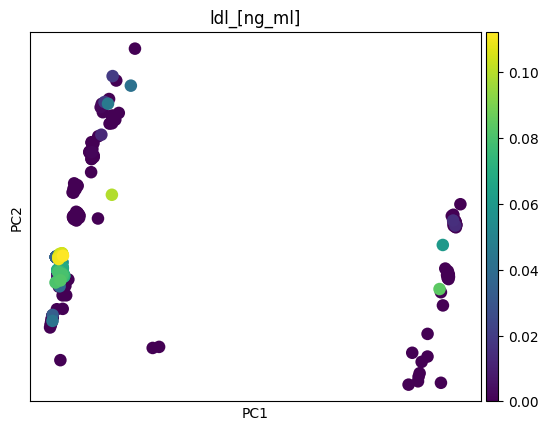

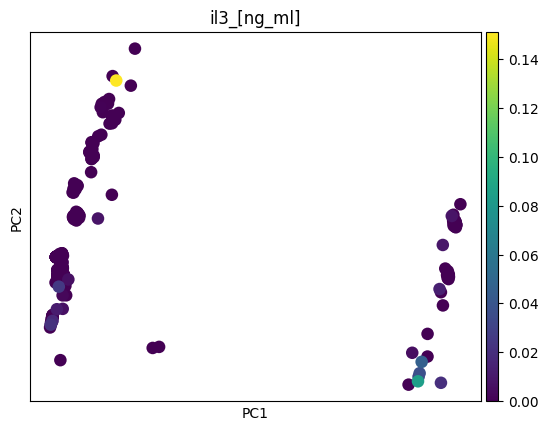

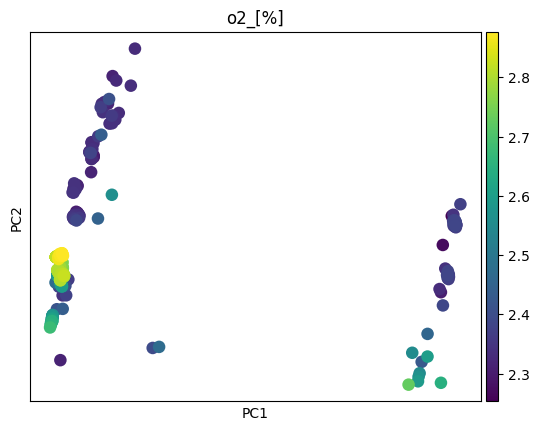

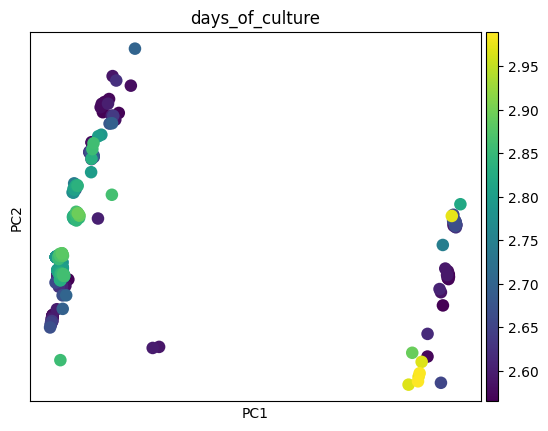

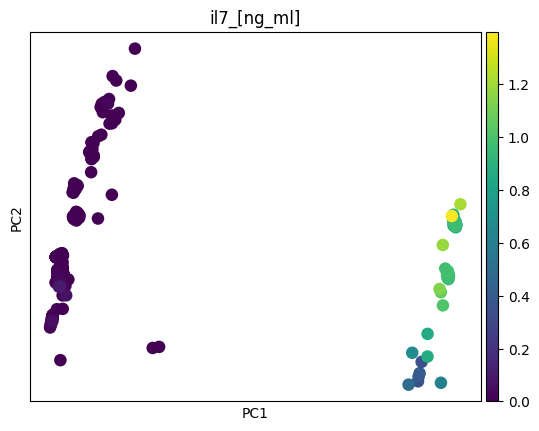

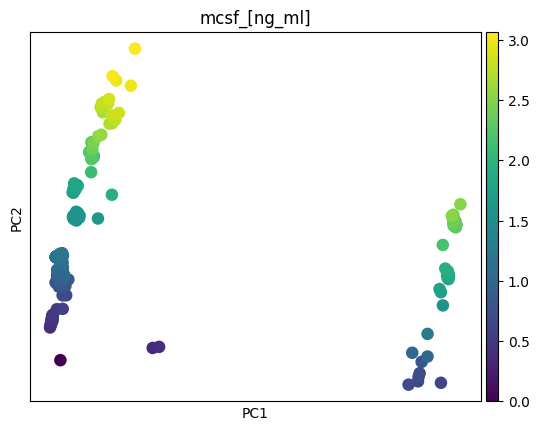

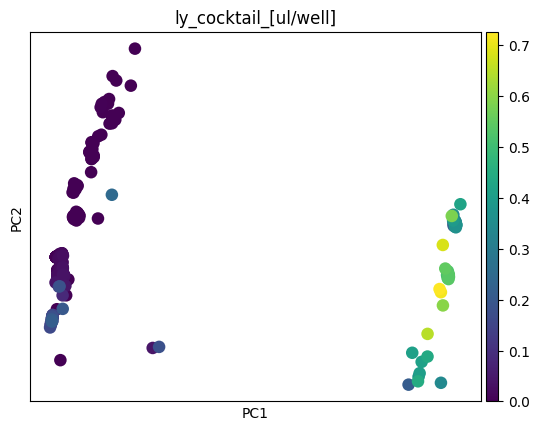

In [266]:
for obs_c in cd14mono_adata.var.index:
    sc.pl.pca(cd14mono_adata, color=obs_c)

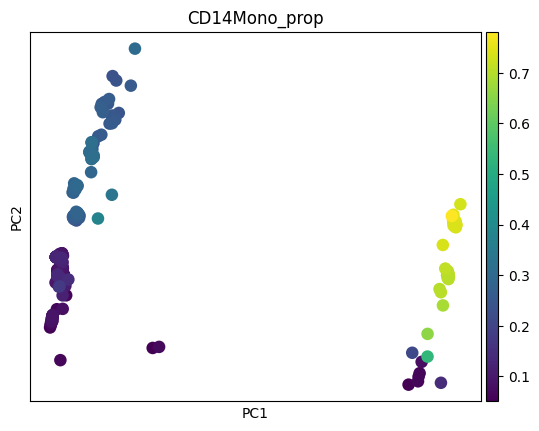

In [267]:
sc.pl.pca(cd14mono_adata, color="CD14Mono_prop")

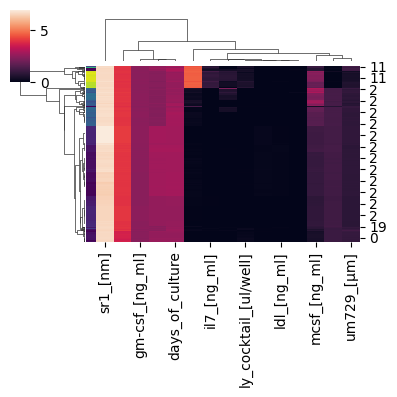

In [268]:
prop_values = cd14mono_adata.obs['CD14Mono_prop'].values

norm = mcolors.Normalize(vmin=prop_values.min(), vmax=prop_values.max())
cmap = plt.cm.viridis
row_colors = [cmap(norm(x)) for x in prop_values]

g = sns.clustermap(
    cd14mono_prot,
    figsize=(4, 4),
    row_colors=row_colors
)

## CD16Mono

In [283]:
cd16mono = filtered_df_loop3_monocytes["CD16Mono"].reset_index()
cd16mono_prop = cd16mono["CD16Mono_prop"]

In [284]:
cd16mono_prot = np.log1p(cd16mono.loc[:, protocol_cols_loop3])
cd16mono_adata = sc.AnnData(X=cd16mono_prot, obs=cd16mono.loc[:, ['CD16Mono_prop', 'filtering_step']])

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [285]:
sc.pp.pca(cd16mono_adata)

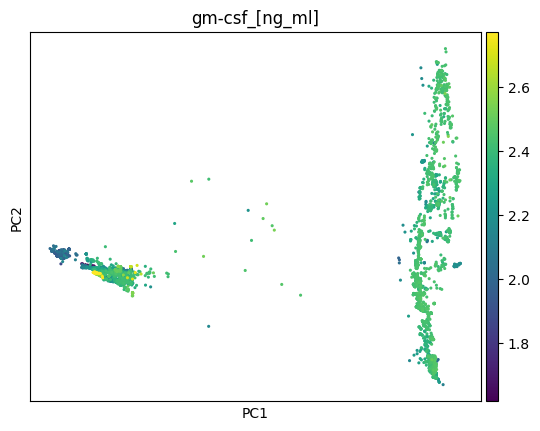

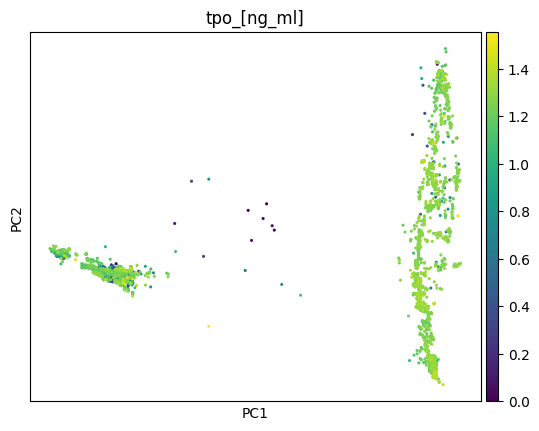

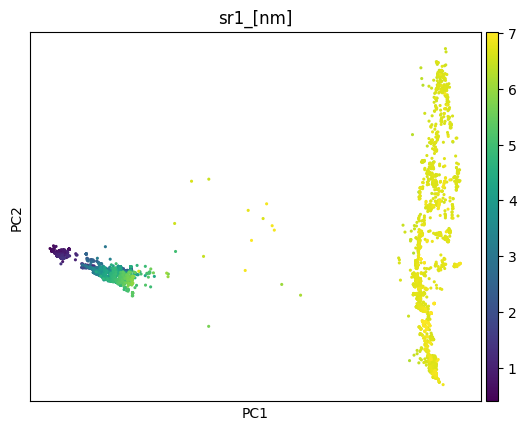

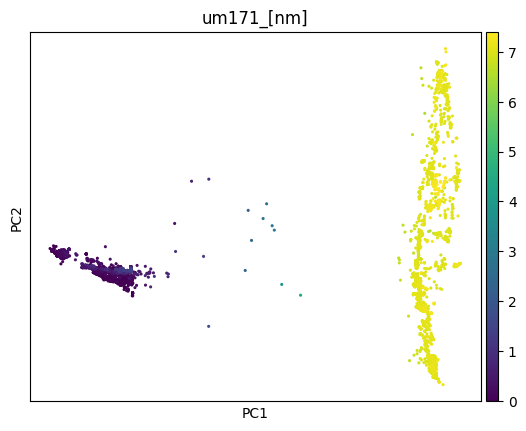

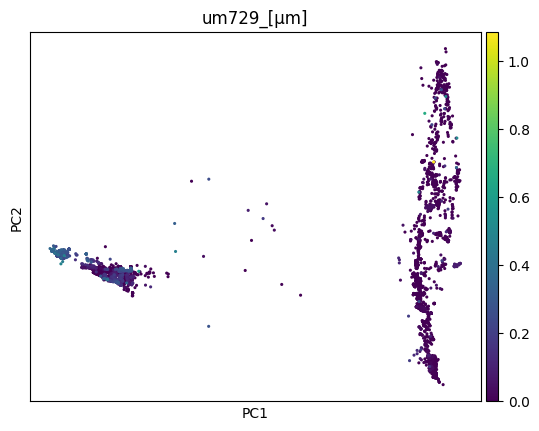

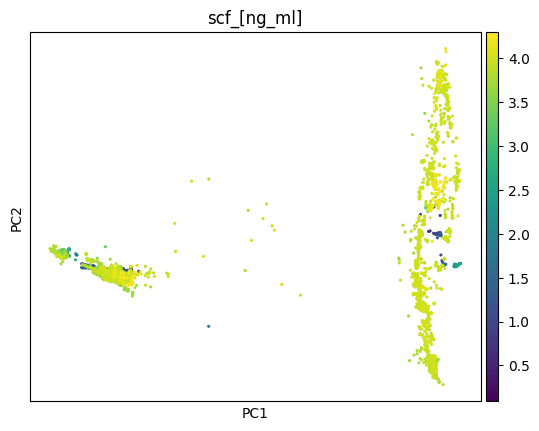

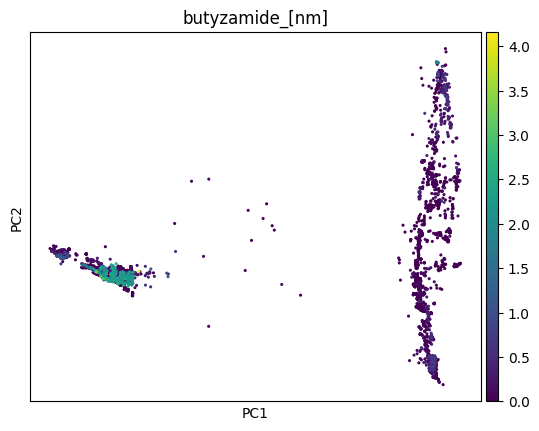

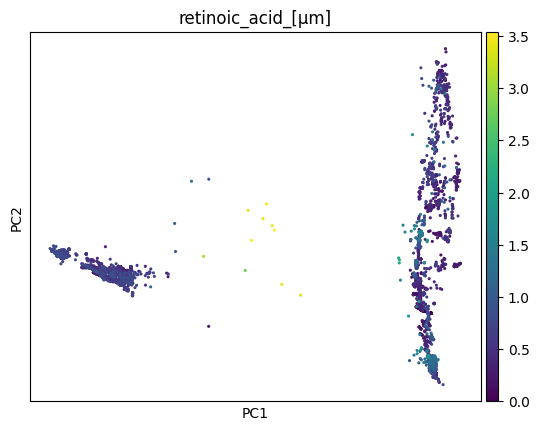

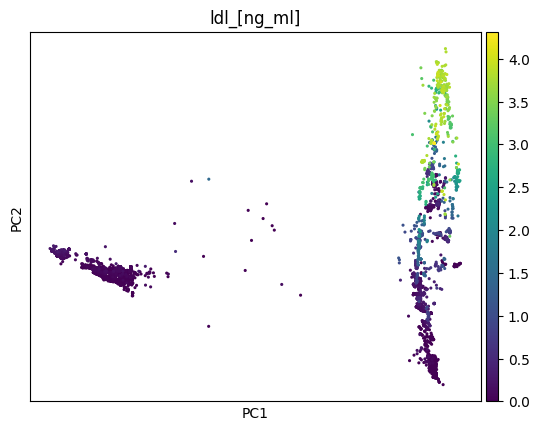

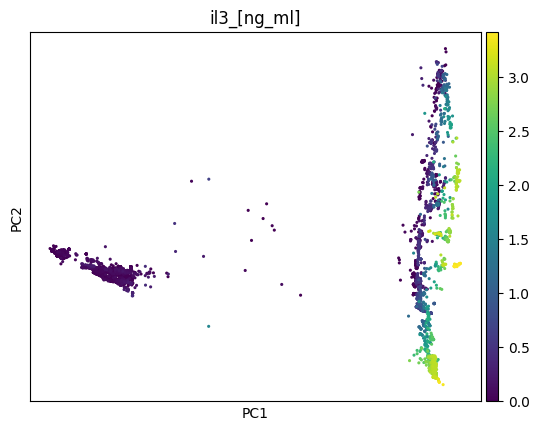

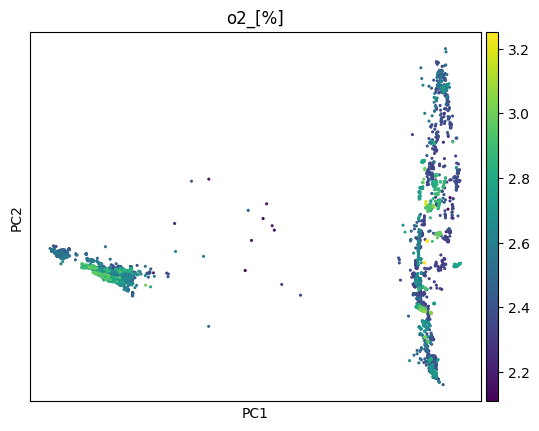

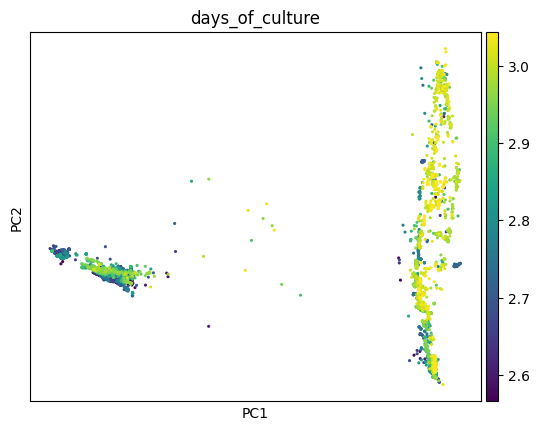

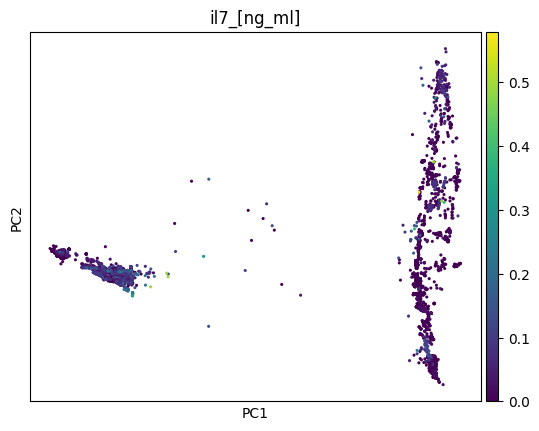

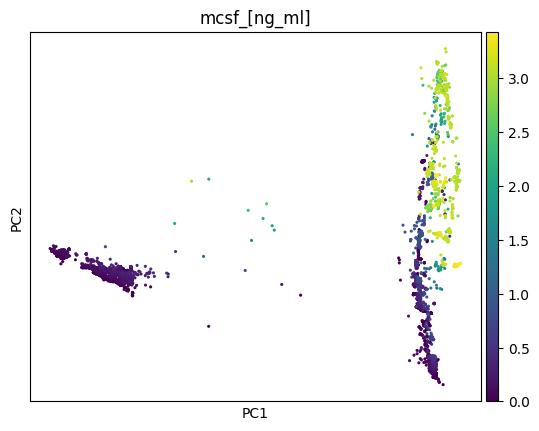

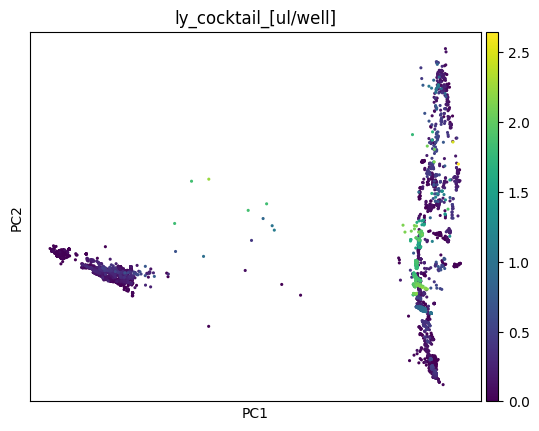

In [286]:
for obs_c in cd16mono_adata.var.index:
    sc.pl.pca(cd16mono_adata, color=obs_c, s=20)

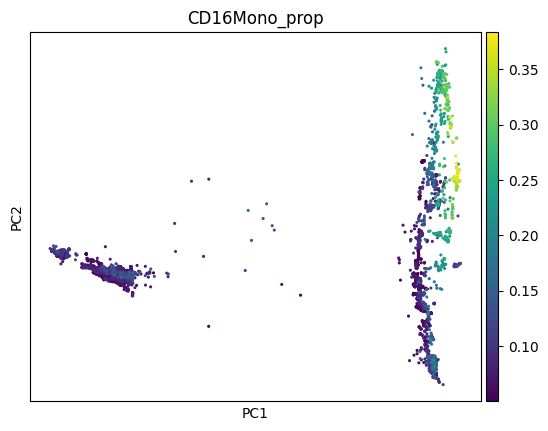

In [287]:
sc.pl.pca(cd16mono_adata, color="CD16Mono_prop", s=20)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


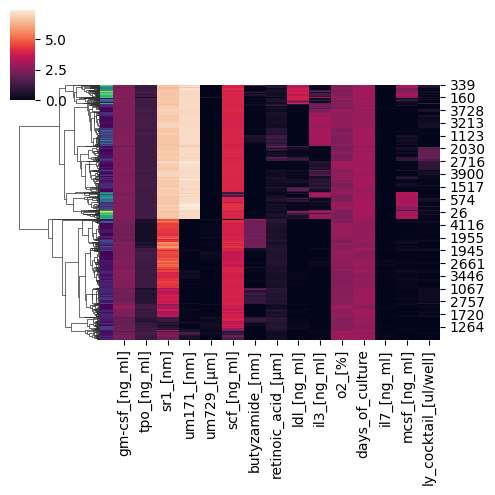

In [288]:
prop_values = cd16mono_adata.obs['CD16Mono_prop'].values

norm = mcolors.Normalize(vmin=prop_values.min(), vmax=prop_values.max())
cmap = plt.cm.viridis
row_colors = [cmap(norm(x)) for x in prop_values]

g = sns.clustermap(
    cd16mono_prot,
    figsize=(5, 5),
    row_colors=row_colors, 
    col_cluster=False
)

In [355]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 5
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'cd16mono_prop': cd16mono_prop.values
}, index=cd16mono_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['cd16mono_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

             mean  count
cluster                 
1        0.212747    339
3        0.112363     13
2        0.105743   2047
5        0.075387   2134
4        0.057330      4
      cluster  cd16mono_prop
4           1       0.374646
23          1       0.358045
27          1       0.354838
28          1       0.353248
33          1       0.347589
...       ...            ...
4273        1       0.052078
4276        1       0.052057
4277        1       0.052054
4309        1       0.051696
4312        1       0.051686

[339 rows x 2 columns]


### Cluster 1

In [356]:
cd16mono_cl1 = cd16mono.loc[cluster_df[cluster_df.cluster==1].index]
cd16mono_cl1 = cd16mono_cl1.sort_values(by="target_ct_loss_std")
cd16mono_cl1_best = cd16mono_cl1.iloc[:3]

In [357]:
cd16mono_cl1.shape

(339, 23)

<Axes: >

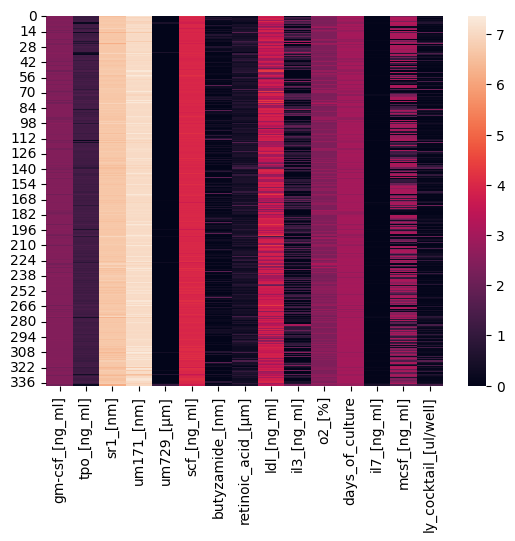

In [358]:
sns.heatmap(np.log1p(cd16mono_cl1.loc[:, protocol_cols_loop3].values), 
           xticklabels=protocol_cols_loop3)

In [359]:
cd16mono_cl1_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/clusters_loop3_cd16/cl_1.csv")

## Cluster 2

In [360]:
cd16mono_cl2 = cd16mono.loc[cluster_df[cluster_df.cluster==2].index]
cd16mono_cl2 = cd16mono_cl2.sort_values(by="target_ct_loss_std")
cd16mono_cl2_best = cd16mono_cl2.iloc[:3]

<Axes: >

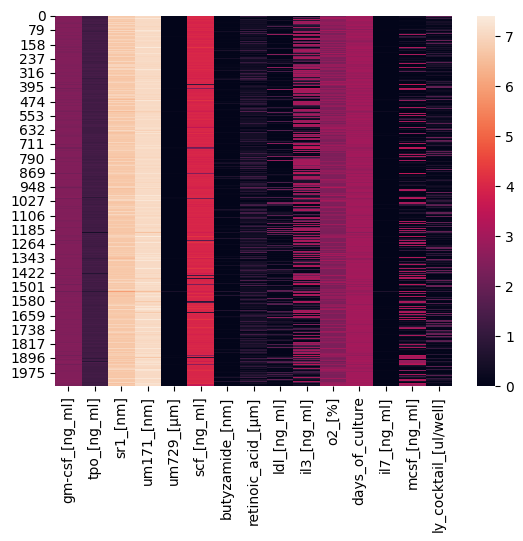

In [361]:
sns.heatmap(np.log1p(cd16mono_cl2.loc[:, protocol_cols_loop3].values), 
           xticklabels=protocol_cols_loop3)

In [362]:
print(cd16mono_cl2.shape)
cd16mono_cl2_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/clusters_loop3_cd16/cl_2.csv")

(2047, 23)


## Cluster 3

In [365]:
cd16mono_cl3 = cd16mono.loc[cluster_df[cluster_df.cluster==3].index]
cd16mono_cl3 = cd16mono_cl3.sort_values(by="target_ct_loss_std")
cd16mono_cl3_best = cd16mono_cl3.iloc[:3]

<Axes: >

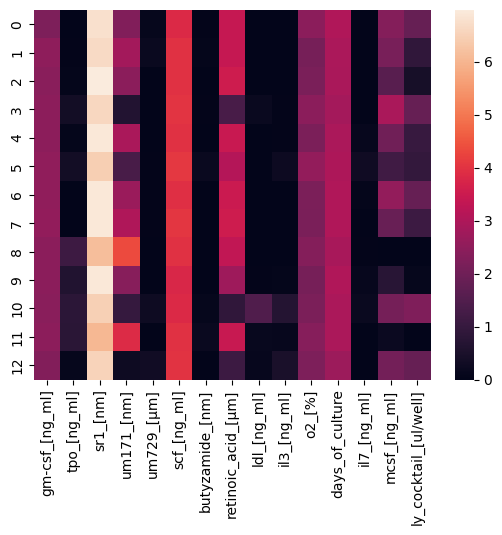

In [366]:
sns.heatmap(np.log1p(cd16mono_cl3.loc[:, protocol_cols_loop3].values), 
           xticklabels=protocol_cols_loop3)

In [368]:
print(cd16mono_cl3.shape)
cd16mono_cl3_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/clusters_loop3_cd16/cl_3.csv")

(13, 23)


## Cluster 4

In [370]:
cd16mono_cl4 = cd16mono.loc[cluster_df[cluster_df.cluster==4].index]
cd16mono_cl4 = cd16mono_cl4.sort_values(by="target_ct_loss_std")
cd16mono_cl4_best = cd16mono_cl4.iloc[:3]

In [371]:
cd16mono_cl4.shape

(4, 23)

<Axes: >

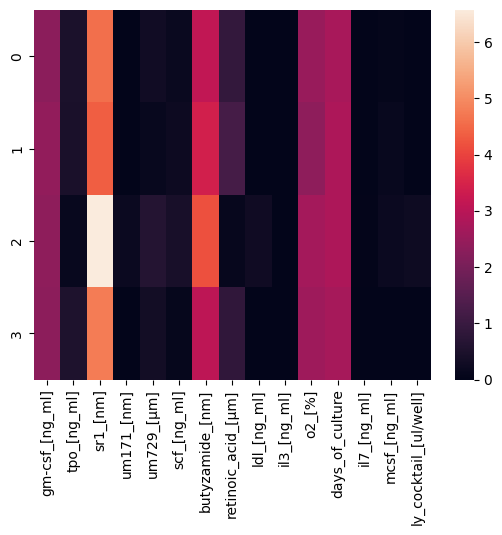

In [372]:
sns.heatmap(np.log1p(cd16mono_cl4.loc[:, protocol_cols_loop3].values), 
           xticklabels=protocol_cols_loop3)

In [373]:
print(cd16mono_cl4.shape)
cd16mono_cl4_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/clusters_loop3_cd16/cl_4.csv")

(4, 23)


## Cluster 5

In [376]:
cd16mono_cl5 = cd16mono.loc[cluster_df[cluster_df.cluster==5].index]
cd16mono_cl5 = cd16mono_cl5.sort_values(by="target_ct_loss_std")
cd16mono_cl5_best = cd16mono_cl5.iloc[:3]

<Axes: >

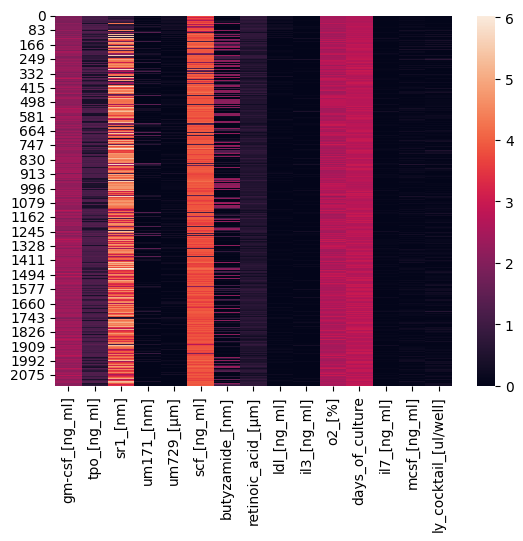

In [378]:
sns.heatmap(np.log1p(cd16mono_cl5.loc[:, protocol_cols_loop3].values), 
           xticklabels=protocol_cols_loop3)

In [379]:
cd16mono_cl5_best.to_csv("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/clusters_loop3_cd16/cl_5.csv")